In [41]:
import os
import copy

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from tqdm.auto import tqdm

from A_market_model_greeks import *
from B_MDP_state_generator import *
from C_trading_environment import *
from D_quantile_regression import *
from E_actor_critic_networks import *
from F_d4pg_qr_algorithm import ReplayBuffer, train, compute_state_scale
from G_parallel_evaluation import evaluate_policy_parallel
from H_parallel_training import train_jobs_parallel


def pick_device():
    print(f"Torch: {torch.__version__} (CUDA runtime: {torch.version.cuda})")

    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        cc = torch.cuda.get_device_capability(0)
        print(f"CUDA device detected: cuda:0 ({gpu_name}, CC={cc[0]}.{cc[1]})")

        try:
            _ = torch.arange(1, 4, device="cuda:0")
            print("CUDA smoke test: OK")
            return torch.device("cuda:0")
        except Exception as e:
            print(f"CUDA smoke test failed: {type(e).__name__}: {e}")
            print("Falling back to CPU. Your GPU architecture is newer than this torch build.")
            return torch.device("cpu")

    print("CUDA unavailable: using CPU")
    return torch.device("cpu")


DEVICE = pick_device()
print("Selected device:", DEVICE)


Torch: 2.11.0+cu128 (CUDA runtime: 12.8)
CUDA device detected: cuda:0 (NVIDIA GeForce RTX 5060 Laptop GPU, CC=12.0)
CUDA smoke test: OK
Selected device: cuda:0


In [42]:
def _make_config(v_value=0.0, rho_value=0.0, gamma_only_state=True):
    """Constant-vol config (paper section 4.2) used for Figure 2."""
    state_dim = 3 if bool(gamma_only_state) else 5
    return {
        "env": {
            "r": 0.0,
            "q": 0.0,
            "v": float(v_value),
            "rho": float(rho_value),
            "lambda_day": 1.0,
            "kappa": 0.01,  # 1% target kappa for Figure 2
            "contract_size": 100.0,
            "delta_hedge": True,
            "gamma_only_state": bool(gamma_only_state),
            "T_days": 30,
            "dt": 1 / 252,
            "T_client_days": 60,
            "T_hedge_days": 30,
            "S0": 10.0,
            "sigma0": 0.3,
        },
        "model": {
            "state_dim": state_dim,
            "action_dim": 1,
            "M": 100,
            "hidden": 256,
            "n_layers": 3,
        },
        "train": {
            "buffer_capacity": 200_000,
            "batch_size": 256,
            "updates_per_step": 4,
            "gamma": 1.0,
            "tau_soft": 0.005,
            "alpha": 0.95,
            "lambda_std": 1.645,
            "k_huber": 1.0,
            "lr_actor": 1e-4,
            "lr_critic": 1e-4,
            "noise_std": 0.10,
            "warmup_steps": 1_000,
            "log_every": 0,
        },
    }


def format_kappa(kappa):
    return f"{100.0 * float(kappa):.1f}%"


OBJECTIVES = ["mean_std", "var", "cvar"]
SEED_BASE = 123
N_EPISODES = 1000
N_EVAL = 2000

# Two setups for Figure 2 comparison
CONFIG_FIG2_GAMMA_ONLY = _make_config(gamma_only_state=True)
CONFIG_FIG2_GAMMA_VEGA = _make_config(gamma_only_state=False)

# Backward-compat alias used by helper wrappers
CONFIG_FIG2 = CONFIG_FIG2_GAMMA_ONLY

EVAL_MAX_WORKERS = max(1, (os.cpu_count() or 2) - 1)
TRAIN_MAX_WORKERS = max(1, (os.cpu_count() or 2) - 2)
print(f"Train workers: {TRAIN_MAX_WORKERS}   Eval workers: {EVAL_MAX_WORKERS}")



Train workers: 14   Eval workers: 15


In [43]:
def set_seed(seed):
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


In [44]:
def _loss_objective_value(samples, objective, alpha=0.95, lambda_std=1.645):
    s = np.asarray(samples, dtype=float)
    obj = str(objective).lower()

    if obj == "mean_std":
        return float(s.mean() + float(lambda_std) * s.std(ddof=0))

    var_alpha = float(np.quantile(s, alpha))
    if obj == "var":
        return var_alpha

    if obj == "cvar":
        tail = s[s >= var_alpha]
        return float(tail.mean()) if tail.size else var_alpha

    raise ValueError("Unknown objective. Choose from {'mean_std','var','cvar'}.")


def _actor_state_cpu(actor):
    return {k: v.detach().cpu() for k, v in actor.state_dict().items()}


def evaluate_policy(
    env,
    actor=None,
    actor_state_dict=None,
    actor_kwargs=None,
    benchmark_strategy=None,
    n_eval=200,
    alpha=0.95,
    lambda_std=1.645,
    state_scale=None,
    episode_seeds=None,
    max_workers=None,
):
    """
    Wrapper over process-parallel evaluator.
    Exactly one policy input must be provided:
      - actor
      - actor_state_dict (+ actor_kwargs)
      - benchmark_strategy
    """
    using_actor = actor is not None
    using_actor_sd = actor_state_dict is not None
    using_benchmark = benchmark_strategy is not None

    if int(using_actor) + int(using_actor_sd) + int(using_benchmark) != 1:
        raise ValueError("Provide exactly one of actor, actor_state_dict, or benchmark_strategy.")

    if max_workers is None:
        max_workers = EVAL_MAX_WORKERS

    env_params = dict(env["params"])

    if actor is not None:
        actor_state_dict = _actor_state_cpu(actor)
        actor_kwargs = {
            "state_dim": int(CONFIG_FIG2["model"].get("state_dim", 5)),
            "hidden": int(CONFIG_FIG2["model"].get("hidden", 256)),
            "n_layers": int(CONFIG_FIG2["model"].get("n_layers", 3)),
        }

    if actor_state_dict is not None:
        actor_kwargs = dict(actor_kwargs or {
            "state_dim": int(CONFIG_FIG2["model"].get("state_dim", 5)),
            "hidden": int(CONFIG_FIG2["model"].get("hidden", 256)),
            "n_layers": int(CONFIG_FIG2["model"].get("n_layers", 3)),
        })
        return evaluate_policy_parallel(
            env_params=env_params,
            n_eval=n_eval,
            alpha=alpha,
            lambda_std=lambda_std,
            episode_seeds=episode_seeds,
            actor_state_dict=actor_state_dict,
            actor_kwargs=actor_kwargs,
            state_scale=state_scale,
            max_workers=max_workers,
        )

    return evaluate_policy_parallel(
        env_params=env_params,
        n_eval=n_eval,
        alpha=alpha,
        lambda_std=lambda_std,
        episode_seeds=episode_seeds,
        benchmark_strategy=benchmark_strategy,
        max_workers=max_workers,
    )


In [45]:
def plot_figure2_gain_distribution(gain_samples_dict):
    names = list(gain_samples_dict.keys())
    colors = {
        "Delta-Neutral": "tab:blue",
        "Delta-Gamma-Neutral": "tab:orange",
        "RL": "tab:green",
        "RL (VaR95)": "tab:green",
        "RL (Gamma-only)": "tab:green",
        "RL (Gamma+Vega)": "tab:red",
    }

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(16, 7),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
    )

    all_vals = np.concatenate([np.asarray(gain_samples_dict[k], dtype=float) for k in names])
    x_min = float(np.min(all_vals)) - 5.0
    x_max = float(np.max(all_vals)) + 5.0
    x_grid = np.linspace(x_min, x_max, 800)

    for i, name in enumerate(names):
        g = np.asarray(gain_samples_dict[name], dtype=float)
        color = colors.get(name, None)

        if g.size > 1 and np.std(g) > 1e-12:
            kde = gaussian_kde(g)
            axes[0].plot(x_grid, kde(x_grid), label=name, color=color, lw=1.5)
        else:
            axes[0].axvline(float(np.mean(g)), label=name, color=color, lw=1.5)

        y_level = float(i)
        axes[1].plot(g, np.full_like(g, y_level), "|", color=color, markersize=8, alpha=0.9)

    axes[0].set_ylabel("density")
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(loc="upper right")

    axes[1].set_yticks(range(len(names)))
    axes[1].set_yticklabels(names)
    axes[1].set_xlabel("gain")
    axes[1].grid(True, alpha=0.25)

    plt.suptitle(
        "FIGURE 2\nComparison of gain distribution for delta hedging, delta-gamma-neutral hedging, RL (Gamma-only), and RL (Gamma+Vega) at 1% transaction cost",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()



In [46]:
# ------------------------------
# RL training for Figure 2
# ------------------------------

# A) Gamma-only setup (paper section 4.2): train 3 objectives
if (
    "trained_fig2_gamma_only" in globals()
    and isinstance(trained_fig2_gamma_only, dict)
    and all(obj in trained_fig2_gamma_only for obj in OBJECTIVES)
):
    print("\n=== Gamma-only training already available, skipping retrain ===")
else:
    fig2_jobs = []
    for j, objective in enumerate(OBJECTIVES):
        fig2_jobs.append({
            "job_id": f"fig2_gamma_only::{objective}",
            "params": CONFIG_FIG2_GAMMA_ONLY,
            "objective": objective,
            "seed": SEED_BASE + j,
            "n_episodes": N_EPISODES,
            "meta": {"objective": objective, "setup": "gamma_only"},
        })

    print("\n=== Training agents for Figure 2 - Gamma-only (3 objectives, kappa=1%) ===")
    res_fig2 = train_jobs_parallel(
        fig2_jobs, max_workers=TRAIN_MAX_WORKERS, show_progress=True, desc="Train Fig2 Gamma-only"
    )

    trained_fig2_gamma_only = {}
    for res in res_fig2:
        obj = res["meta"]["objective"]
        trained_fig2_gamma_only[obj] = {
            "actor_state_dict": res["actor_state_dict"],
            "actor_kwargs": res["actor_kwargs"],
            "history": res["history"],
            "state_scale": np.asarray(res["state_scale"], dtype=np.float32),
        }
    print("Gamma-only training done:", list(trained_fig2_gamma_only.keys()))

# Backward-compat alias used by existing diagnostics cell
trained_fig2 = trained_fig2_gamma_only

# B) Gamma+Vega setup: train only VaR objective for Figure 2 red curve
if (
    "trained_fig2_gamma_vega_var" in globals()
    and isinstance(trained_fig2_gamma_vega_var, dict)
    and "actor_state_dict" in trained_fig2_gamma_vega_var
):
    print("\n=== Gamma+Vega VaR agent already available, skipping retrain ===")
else:
    # Reload core modules to avoid stale signatures in long-running kernels.
    import importlib
    import B_MDP_state_generator as _bmsg_mod
    import C_trading_environment as _env_mod
    import H_parallel_training as _hpt_mod

    _bmsg_mod = importlib.reload(_bmsg_mod)
    _env_mod = importlib.reload(_env_mod)
    _hpt_mod = importlib.reload(_hpt_mod)

    train_jobs_parallel = _hpt_mod.train_jobs_parallel

    fig2_gv_job = [{
        "job_id": "fig2_gamma_vega::var",
        "params": CONFIG_FIG2_GAMMA_VEGA,
        "objective": "var",
        "seed": SEED_BASE + 100,
        "n_episodes": N_EPISODES,
        "meta": {"objective": "var", "setup": "gamma_vega"},
    }]

    print("\n=== Training Figure 2 extra agent - Gamma+Vega (VaR, kappa=1%) ===")
    res_fig2_gv = train_jobs_parallel(
        fig2_gv_job, max_workers=1, show_progress=True, desc="Train Fig2 Gamma+Vega VaR"
    )

    res_gv = res_fig2_gv[0]
    trained_fig2_gamma_vega_var = {
        "actor_state_dict": res_gv["actor_state_dict"],
        "actor_kwargs": res_gv["actor_kwargs"],
        "history": res_gv["history"],
        "state_scale": np.asarray(res_gv["state_scale"], dtype=np.float32),
    }
    print("Gamma+Vega training done: ['var']")




=== Gamma-only training already available, skipping retrain ===

=== Training Figure 2 extra agent - Gamma+Vega (VaR, kappa=1%) ===








Train Fig2 Gamma+Vega VaR: 100%|██████████| 1/1 [2:26:49<00:00, 8809.17s/it]

Gamma+Vega training done: ['var']


In [47]:
def _smooth(arr, window=200):
    arr = np.asarray(arr, dtype=float)
    window = int(max(1, window))
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    pad = np.pad(arr, (window // 2, window - window // 2 - 1), mode="edge")
    return np.convolve(pad, kernel, mode="valid")[:len(arr)]


def plot_training_diagnostics(trained_dict, samples_by_objective, objectives,
                              smooth_window=200, title_suffix=""):
    """
    5-panel training-diagnostics figure:
      top row    : episode returns | actor loss | critic loss
      bottom row : loss histogram  | empirical CDF
    """
    obj_colors = {"mean_std": "tab:blue", "var": "tab:orange", "cvar": "tab:green"}
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for objective in objectives:
        h = trained_dict[objective]["history"]
        color = obj_colors[objective]

        # Episode returns
        ret = np.asarray(h["returns"], dtype=float)
        axes[0, 0].plot(ret, color=color, alpha=0.30, lw=0.6)
        axes[0, 0].plot(_smooth(ret, smooth_window), color=color, lw=1.8, label=objective)

        # Actor / critic loss (NaN before warmup)
        a_arr = np.asarray(h["actor_loss"], dtype=float)
        c_arr = np.asarray(h["critic_loss"], dtype=float)
        valid = ~np.isnan(a_arr)
        steps = np.where(valid)[0]
        a_v, c_v = a_arr[valid], c_arr[valid]
        axes[0, 1].plot(steps, a_v, color=color, alpha=0.20, lw=0.5)
        axes[0, 1].plot(steps, _smooth(a_v, smooth_window), color=color, lw=1.8, label=objective)
        axes[0, 2].plot(steps, c_v, color=color, alpha=0.20, lw=0.5)
        axes[0, 2].plot(steps, _smooth(c_v, smooth_window), color=color, lw=1.8, label=objective)

        # Loss histogram
        losses = np.asarray(samples_by_objective[objective], dtype=float)
        axes[1, 0].hist(losses, bins=60, density=True, alpha=0.40, color=color, label=objective)

        # Empirical CDF
        sl = np.sort(losses)
        cdf = np.arange(1, len(sl) + 1) / len(sl)
        axes[1, 1].plot(sl, cdf, color=color, lw=1.8, label=objective)

    for ax, title in zip(axes[0], ["Episode returns", "Actor loss", "Critic loss"]):
        ax.set_title(title)
        ax.set_xlabel("step")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)
    axes[0, 0].set_ylabel("value")

    axes[1, 0].set_title("Loss distribution (hist)")
    axes[1, 0].set_xlabel("episode loss")
    axes[1, 0].set_ylabel("density")
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].grid(True, alpha=0.25)

    axes[1, 1].set_title("Empirical CDF")
    axes[1, 1].set_xlabel("episode loss")
    axes[1, 1].set_ylabel("probability")
    axes[1, 1].legend(fontsize=9)
    axes[1, 1].grid(True, alpha=0.25)

    axes[1, 2].axis("off")

    n_ep = len(trained_dict[objectives[0]]["history"]["returns"])
    plt.suptitle(
        f"Training diagnostics - kappa=1% ({n_ep:,} episodes){title_suffix}",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()



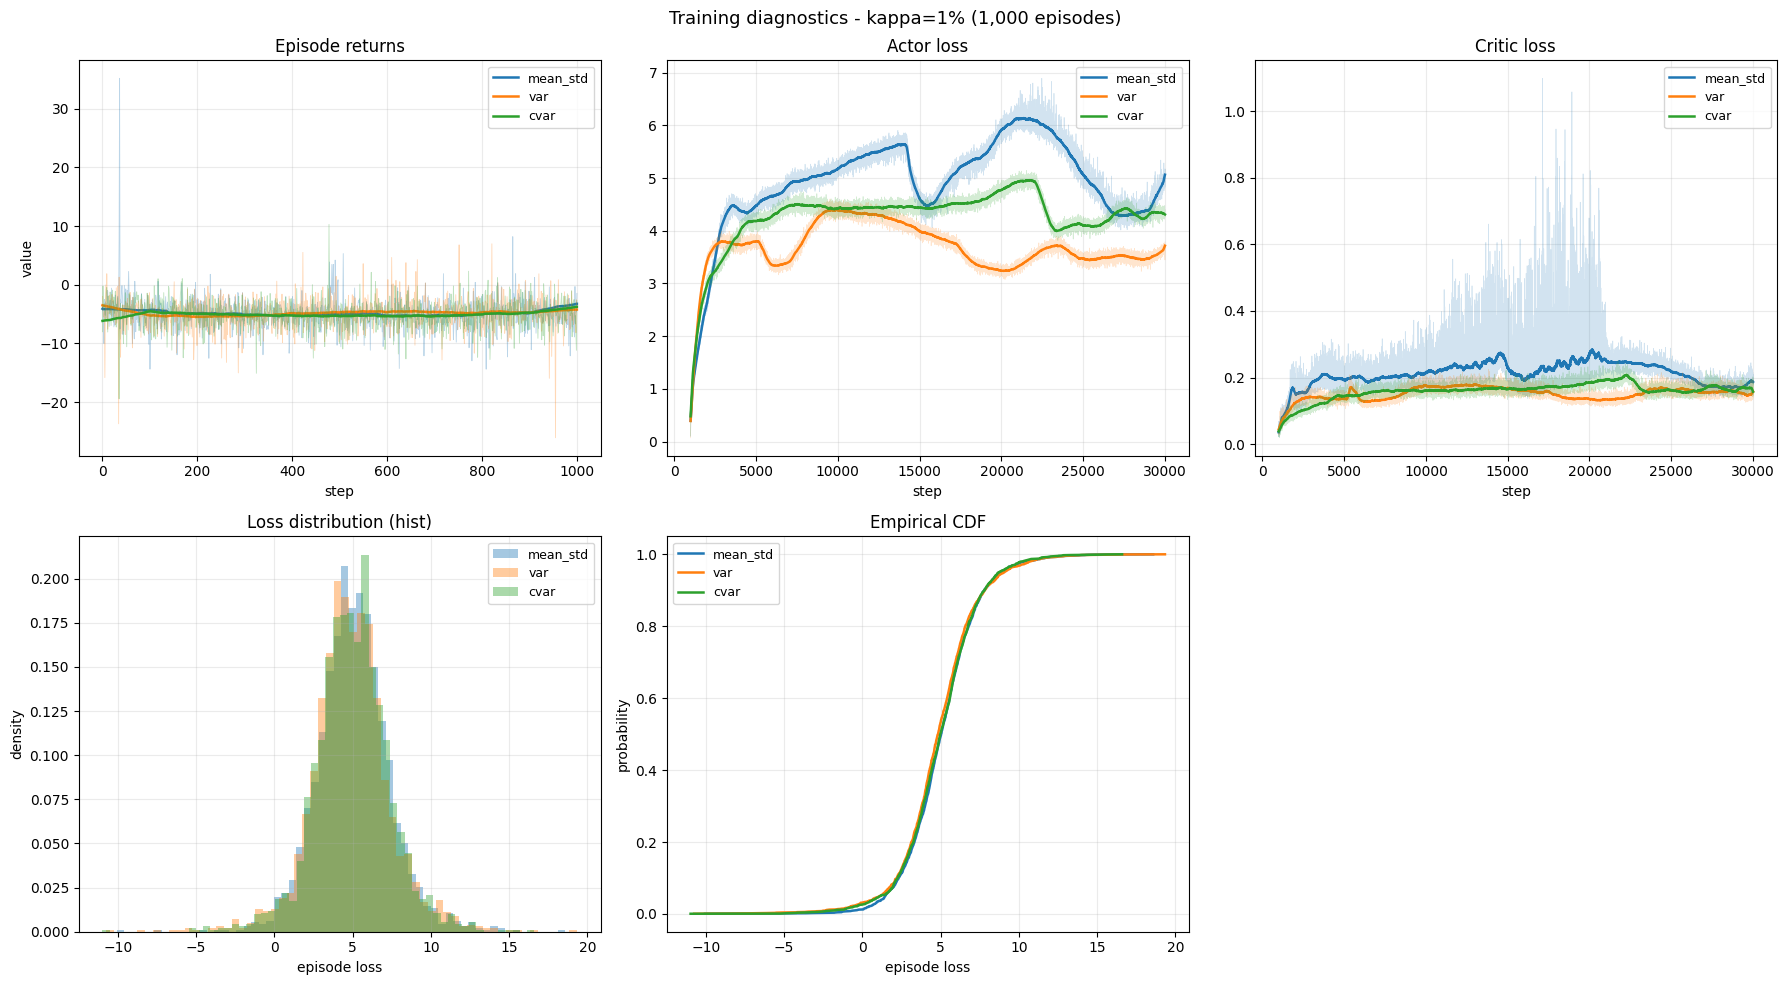

In [48]:
import importlib

import C_trading_environment as _env_mod
import G_parallel_evaluation as _gpe_mod

# Ensure eval uses latest environment/evaluator implementation.
_env_mod = importlib.reload(_env_mod)
_gpe_mod = importlib.reload(_gpe_mod)
evaluate_policy_parallel = _gpe_mod.evaluate_policy_parallel

alpha_eval = float(CONFIG_FIG2_GAMMA_ONLY["train"]["alpha"])
lambda_std_eval = float(CONFIG_FIG2_GAMMA_ONLY["train"].get("lambda_std", 1.645))

eval_episode_seeds = [300_000 + ep for ep in range(N_EVAL)]

# --- Benchmark strategies (gamma-only setup for paper Figure 2 baseline) ---
samples_benchmarks = {}
for strategy in ("delta_neutral", "delta_gamma_neutral"):
    eval_env = init_env(CONFIG_FIG2_GAMMA_ONLY["env"], seed=9_000)
    _, s = evaluate_policy(
        env=eval_env,
        benchmark_strategy=strategy,
        n_eval=N_EVAL,
        alpha=alpha_eval,
        lambda_std=lambda_std_eval,
        episode_seeds=eval_episode_seeds,
    )
    samples_benchmarks[strategy] = np.asarray(s, dtype=float)

# --- RL agents (gamma-only, all 3 objectives, for diagnostics panel) ---
samples_rl_gamma_only = {}
for o_i, objective in enumerate(OBJECTIVES):
    tr = trained_fig2_gamma_only[objective]
    eval_env = init_env(CONFIG_FIG2_GAMMA_ONLY["env"], seed=10_000 + o_i)
    _, s_rl = evaluate_policy(
        env=eval_env,
        actor_state_dict=tr["actor_state_dict"],
        actor_kwargs=tr["actor_kwargs"],
        n_eval=N_EVAL,
        alpha=alpha_eval,
        lambda_std=lambda_std_eval,
        state_scale=tr["state_scale"],
        episode_seeds=eval_episode_seeds,
    )
    samples_rl_gamma_only[objective] = np.asarray(s_rl, dtype=float)

# Backward-compat alias for the training diagnostics plotting function
samples_rl = samples_rl_gamma_only

# --- Extra RL agent (gamma+vega, VaR only) for Figure 2 red curve ---
eval_env_gv = init_env(CONFIG_FIG2_GAMMA_VEGA["env"], seed=20_000)
_, s_rl_gv_var = evaluate_policy(
    env=eval_env_gv,
    actor_state_dict=trained_fig2_gamma_vega_var["actor_state_dict"],
    actor_kwargs=trained_fig2_gamma_vega_var["actor_kwargs"],
    n_eval=N_EVAL,
    alpha=alpha_eval,
    lambda_std=lambda_std_eval,
    state_scale=trained_fig2_gamma_vega_var["state_scale"],
    episode_seeds=eval_episode_seeds,
)
samples_rl_gamma_vega_var = np.asarray(s_rl_gv_var, dtype=float)

# --- Training diagnostics plot (keep gamma-only version) ---
plot_training_diagnostics(trained_fig2_gamma_only, samples_rl_gamma_only, OBJECTIVES)



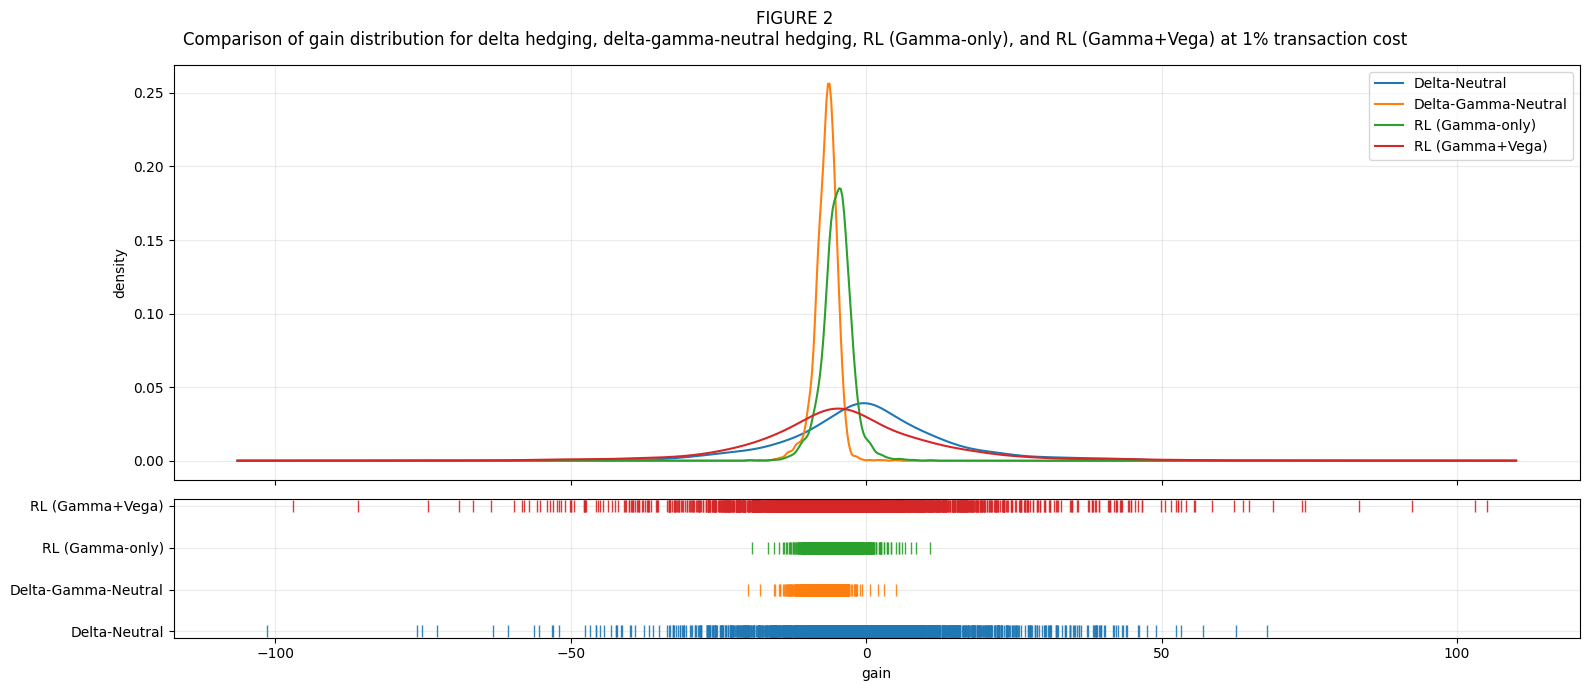

In [49]:
# Figure 2: 4 curves
figure2_gain_samples = {
    "Delta-Neutral": -np.asarray(samples_benchmarks["delta_neutral"], dtype=float),
    "Delta-Gamma-Neutral": -np.asarray(samples_benchmarks["delta_gamma_neutral"], dtype=float),
    "RL (Gamma-only)": -np.asarray(samples_rl_gamma_only["var"], dtype=float),
    "RL (Gamma+Vega)": -np.asarray(samples_rl_gamma_vega_var, dtype=float),
}
plot_figure2_gain_distribution(figure2_gain_samples)



In [50]:
from pathlib import Path
from datetime import datetime
import time
import matplotlib.pyplot as plt

_t0 = time.time()
today_tag = datetime.now().strftime('%Y_%m_%d')

# Re-generate and capture plot 1
_before = set(plt.get_fignums())
_new = sorted(set(plt.get_fignums()) - _before)
fig_plot_1 = plt.figure(_new[-1]) if _new else plt.gcf()

# Re-generate and capture plot 2
_before = set(plt.get_fignums())
_new = sorted(set(plt.get_fignums()) - _before)
fig_plot_2 = plt.figure(_new[-1]) if _new else plt.gcf()

elapsed_sec = int(time.time() - _t0)
mins, secs = divmod(elapsed_sec, 60)
results_name = f'results_day_{today_tag}_temps_{mins:02d}min_{secs:02d}sec'
results_dir = Path('results') / results_name
results_dir.mkdir(parents=True, exist_ok=True)

plot_1_path = results_dir / 'plot_1_training_diagnostics.png'
plot_2_path = results_dir / 'plot_2_gain_distribution.png'
fig_plot_1.savefig(plot_1_path, dpi=300, bbox_inches='tight')
fig_plot_2.savefig(plot_2_path, dpi=300, bbox_inches='tight')

results_payload = {
    'name': results_name,
    'folder': str(results_dir),
    'elapsed_min_sec': f'{mins:02d}:{secs:02d}',
    'plots': [str(plot_1_path), str(plot_2_path)],
}
globals()[results_name] = results_payload
print(f'Saved 2 plots in: {results_dir}')
print(f'Variable created: {results_name}')
results_payload


Saved 2 plots in: results\results_day_2026_04_01_temps_00min_00sec
Variable created: results_day_2026_04_01_temps_00min_00sec


{'name': 'results_day_2026_04_01_temps_00min_00sec',
 'folder': 'results\\results_day_2026_04_01_temps_00min_00sec',
 'elapsed_min_sec': '00:00',
 'plots': ['results\\results_day_2026_04_01_temps_00min_00sec\\plot_1_training_diagnostics.png',
  'results\\results_day_2026_04_01_temps_00min_00sec\\plot_2_gain_distribution.png']}

<Figure size 640x480 with 0 Axes>